# Regresión Logística aplicada: diagnóstico de cáncer de mama

| | |
|---|---|
| **Autor** | Daniel Felipe León Higuera |
| **Curso** | Introducción a Machine Learning, Semana 6 |
| **Tema** | Regresión Logística, Machine Learning Supervisado |
| **Entorno** | Google Colab (Python 3, scikit-learn 1.5 o superior) |
| **Repositorio** | https://github.com/Danielleon172025/regresion-logistica-cancer |

Este ejercicio resuelve un problema de diagnóstico con 569 casos reales: a partir de medidas del núcleo celular, ¿el tumor es maligno o benigno? El flujo recorre datos, entrenamiento y prueba, `fit()`, `predict()` y `predict_proba()` y métricas, y añade decisiones como elegir variables sin colinealidad, justificar los hiperparámetros, escoger un umbral según el costo de cada error y medir la incertidumbre de los resultados.

## Tabla de contenido
1. Contexto y pregunta
2. Configuración del entorno
3. Datos
4. Exploración (EDA)
5. Partición entrenamiento y prueba
6. Selección de variables por colinealidad (VIF)
7. Modelo y selección de hiperparámetros
8. Comparación de variantes con validación cruzada
9. Entrenamiento final: `predict()` frente a `predict_proba()`
10. Ajuste del umbral de decisión
11. Evaluación en el conjunto de prueba
12. Interpretación de los coeficientes
13. Discusión y conclusiones
14. Referencias

## 1. Contexto y pregunta

El cáncer de mama fue el cáncer más frecuente entre las mujeres colombianas dentro de los once tipos priorizados por la Cuenta de Alto Costo, con una mediana de edad al diagnóstico de 59 años (Cuenta de Alto Costo, 2024). A escala mundial, la OMS estima 2,4 millones de diagnósticos en mujeres y 694 000 muertes en 2024 (Organización Mundial de la Salud, 2026).

La pregunta es si, a partir de un conjunto pequeño de medidas del núcleo celular, se puede predecir que un tumor es maligno. Es un problema de clasificación binaria. Un modelo así no sustituye al patólogo, pero permite estudiar un caso con costos de error muy distintos: pasar por alto un tumor maligno (falso negativo) es más grave que pedir un examen adicional para uno benigno (falso positivo).

Los datos son *Breast Cancer Wisconsin (Diagnostic)*: 569 muestras digitalizadas de biopsias por aspiración con aguja fina, con diagnóstico confirmado. Lo publicó el repositorio UCI (autoría original de Wolberg, Street y Mangasarian, 1995) y scikit-learn lo incluye, así que no hace falta descargar nada.

scikit-learn codifica la etiqueta con 0 = maligno y 1 = benigno. Aquí se invierte (`maligno = 1`) para que la clase positiva sea la de interés, y así el *recall* mide directamente qué porcentaje de tumores malignos se detecta.

## 2. Configuración del entorno

In [1]:
# Librerías del curso: Pandas, NumPy, Matplotlib y Scikit-learn
import os
import platform

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn

from sklearn.base import clone
from sklearn.datasets import load_breast_cancer
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, average_precision_score, balanced_accuracy_score,
                             brier_score_loss, classification_report, confusion_matrix,
                             f1_score, fbeta_score, make_scorer, matthews_corrcoef,
                             precision_recall_curve, precision_score, recall_score,
                             roc_auc_score, roc_curve)
from sklearn.model_selection import (GridSearchCV, StratifiedKFold, TunedThresholdClassifierCV,
                                     cross_val_predict, cross_validate, train_test_split)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# Parámetros del experimento (todos juntos para que no haya valores escondidos)
SEMILLA = 42                  # reproducibilidad
TAMANO_PRUEBA = 0.25
FOLDS = 5                     # validación cruzada estratificada
VALORES_C = [0.01, 0.03, 0.1, 0.3, 1, 3, 10, 30, 100]   # C = inverso de la regularización L2
MAX_ITER = 1000
BETA_UMBRAL = 2               # F2: el recall pesa más que la precisión
UMBRAL_VIF = 5.0
N_BOOTSTRAP = 1000
N_BOOTSTRAP_COEF = 500

ROJO, AZUL, GRIS = "#c0392b", "#2d6cdf", "#7f8c8d"   # maligno, benigno, referencias
os.makedirs("figures", exist_ok=True)

print("Python      :", platform.python_version())
print("NumPy       :", np.__version__)
print("pandas      :", pd.__version__)
print("scikit-learn:", sklearn.__version__)
assert tuple(int(x) for x in sklearn.__version__.split(".")[:2]) >= (1, 5), \
    "Se necesita scikit-learn 1.5 o superior (TunedThresholdClassifierCV)"

Python      : 3.14.3
NumPy       : 2.4.4
pandas      : 3.0.2
scikit-learn: 1.8.0


## 3. Datos

In [2]:
bc = load_breast_cancer(as_frame=True)

# 30 variables originales + etiqueta recodificada (maligno = 1)
completo = bc.data.copy()
completo["maligno"] = (bc.target == 0).astype(int)

# Seis candidatas (promedios del núcleo). Se excluyen perímetro y área porque
# duplican el radio (correlación de 0.99 con él).
candidatas_en = {"mean radius": "radio", "mean texture": "textura",
                 "mean smoothness": "suavidad", "mean concavity": "concavidad",
                 "mean concave points": "puntos_concavos", "mean symmetry": "simetria"}
datos = completo[list(candidatas_en) + ["maligno"]].rename(columns=candidatas_en)

NOMBRES_CANDIDATAS = list(candidatas_en.values())
y = datos["maligno"]
X_cand = datos[NOMBRES_CANDIDATAS]
X30 = completo.drop(columns="maligno")        # solo para la comparación de la sección 8

print("Filas y columnas:", datos.shape)
print("Valores nulos   :", int(datos.isna().sum().sum()))
datos.head()

Filas y columnas: (569, 7)
Valores nulos   : 0


,radio,textura,suavidad,concavidad,puntos_concavos,simetria,maligno
0,17.99,10.38,0.11840,0.3001,0.14710,0.2419,1
1,20.57,17.77,0.08474,0.0869,0.07017,0.1812,1
2,19.69,21.25,0.10960,0.1974,0.12790,0.2069,1
3,11.42,20.38,0.14250,0.2414,0.10520,0.2597,1
4,20.29,14.34,0.10030,0.1980,0.10430,0.1809,1


| Elemento | Variable | Descripción |
|---|---|---|
| Entrada | radio | Radio promedio del núcleo celular |
| Entrada | textura | Desviación estándar de los tonos de gris |
| Entrada | suavidad | Variación local de la longitud del radio |
| Entrada | concavidad | Severidad de las porciones cóncavas del contorno |
| Entrada | puntos_concavos | Número de porciones cóncavas del contorno |
| Entrada | simetria | Simetría del núcleo |
| Objetivo | maligno | 1 = maligno, 0 = benigno |

## 4. Exploración (EDA)

In [3]:
datos.info()
print()
print(datos["maligno"].value_counts().rename({0: "benigno", 1: "maligno"}))
print()
# Media y desviación de cada variable por clase
datos.groupby("maligno")[NOMBRES_CANDIDATAS].agg(["mean", "std"]).round(3)

<class 'pandas.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   radio            569 non-null    float64
 1   textura          569 non-null    float64
 2   suavidad         569 non-null    float64
 3   concavidad       569 non-null    float64
 4   puntos_concavos  569 non-null    float64
 5   simetria         569 non-null    float64
 6   maligno          569 non-null    int64  
dtypes: float64(6), int64(1)
memory usage: 31.2 KB

maligno
benigno    357
maligno    212
Name: count, dtype: int64



radio        textura        suavidad        concavidad         \
           mean    std    mean    std     mean    std       mean    std   
maligno                                                                   
0        12.147  1.781  17.915  3.995    0.092  0.013      0.046  0.043   
1        17.463  3.204  21.605  3.779    0.103  0.013      0.161  0.075   

        puntos_concavos        simetria         
                   mean    std     mean    std  
maligno                                         
0                 0.026  0.016    0.174  0.025  
1                 0.088  0.034    0.193  0.028

Hay 357 casos benignos (62,7 %) y 212 malignos (37,3 %). El desbalance es moderado, pero basta para dos precauciones: estratificar la partición y no juzgar el modelo solo por la exactitud, que engaña cuando las clases están desequilibradas (Google for Developers, 2025b). Un clasificador que dijera siempre "benigno" acertaría el 62,7 %.

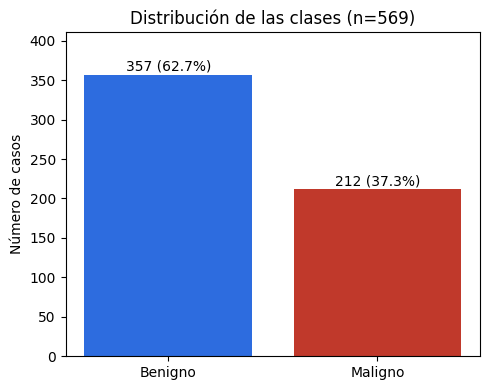

In [4]:
# Figura 1: distribución de clases
conteo = datos["maligno"].value_counts().sort_index()
fig, ax = plt.subplots(figsize=(5, 4))
ax.bar(["Benigno", "Maligno"], conteo.values, color=[AZUL, ROJO])
for i, v in enumerate(conteo.values):
    ax.text(i, v + 5, f"{v} ({v / len(datos):.1%})", ha="center")
ax.set_ylabel("Número de casos")
ax.set_title(f"Distribución de las clases (n={len(datos)})")
ax.set_ylim(0, conteo.max() * 1.15)
fig.tight_layout(); fig.savefig("figures/fig01_distribucion_clases.png", dpi=150); plt.show()

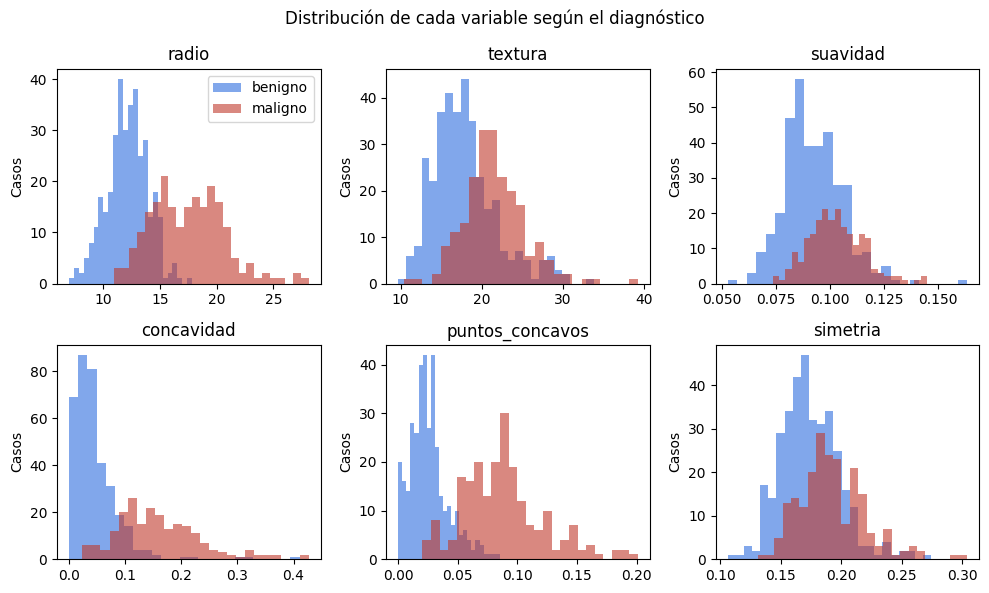

In [5]:
# Figura 2: distribución de cada variable según el diagnóstico
fig, ejes = plt.subplots(2, 3, figsize=(10, 6))
for ax, var in zip(ejes.ravel(), NOMBRES_CANDIDATAS):
    for valor, color, etiqueta in [(0, AZUL, "benigno"), (1, ROJO, "maligno")]:
        ax.hist(datos.loc[datos["maligno"] == valor, var], bins=25, alpha=0.6,
                color=color, label=etiqueta)
    ax.set_title(var); ax.set_ylabel("Casos")
ejes[0, 0].legend()
fig.suptitle("Distribución de cada variable según el diagnóstico")
fig.tight_layout(); fig.savefig("figures/fig02_histogramas_por_clase.png", dpi=150); plt.show()

Los tumores malignos tienen valores más altos en todas las variables. Radio, concavidad y puntos cóncavos son las que más separan las clases, con un solapamiento moderado; textura, suavidad y simetría se solapan mucho más. El radio promedio es de 12,1 en los benignos y de 17,5 en los malignos.

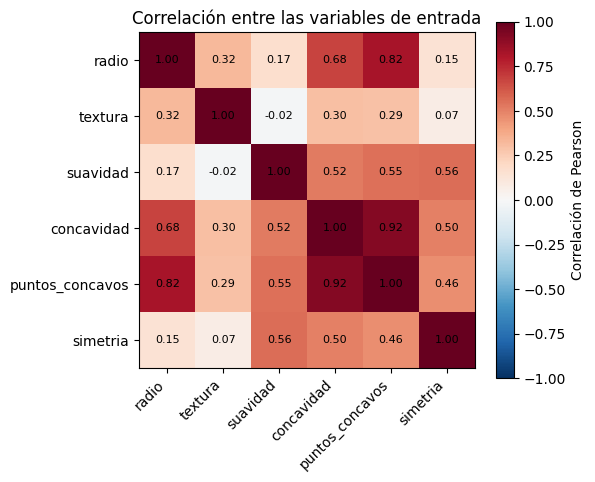

In [6]:
# Figura 3: correlación entre variables candidatas
corr = X_cand.corr()
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1)
fig.colorbar(im, ax=ax, label="Correlación de Pearson")
ax.set_xticks(range(len(corr)), corr.columns, rotation=45, ha="right")
ax.set_yticks(range(len(corr)), corr.columns)
for i in range(len(corr)):
    for j in range(len(corr)):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center", fontsize=8)
ax.set_title("Correlación entre las variables de entrada")
fig.tight_layout(); fig.savefig("figures/fig03_correlacion.png", dpi=150); plt.show()

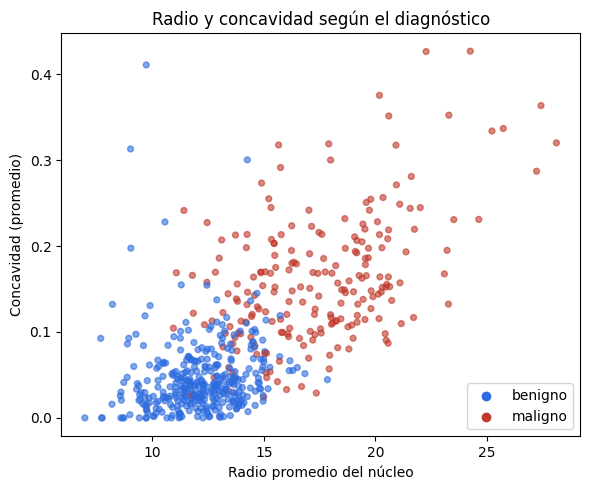

In [7]:
# Figura 4: radio y concavidad según el diagnóstico
fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(datos["radio"], datos["concavidad"], c=datos["maligno"].map({0: AZUL, 1: ROJO}),
           alpha=0.6, s=18)
ax.scatter([], [], c=AZUL, label="benigno"); ax.scatter([], [], c=ROJO, label="maligno")
ax.set_xlabel("Radio promedio del núcleo"); ax.set_ylabel("Concavidad (promedio)")
ax.set_title("Radio y concavidad según el diagnóstico"); ax.legend()
fig.tight_layout(); fig.savefig("figures/fig04_dispersion_radio_concavidad.png", dpi=150); plt.show()

Las correlaciones entre varias candidatas son altas: concavidad con puntos cóncavos (0,92), radio con puntos cóncavos (0,82) y radio con concavidad (0,68). Con estos valores no se puede asumir que las variables aporten información independiente; la sección 6 lo mide con el VIF. Los casos intermedios del gráfico de dispersión, donde se mezclan los dos colores, son los que más dudas darán al modelo.

## 5. Partición entrenamiento y prueba

La partición se hace antes de cualquier decisión basada en los datos (qué variables usar, qué C, qué umbral). El conjunto de prueba se usa una sola vez, al final; si se consultara repetidamente, dejaría de ser una estimación honesta (Google for Developers, 2025c). Con `stratify=y` ambos subconjuntos conservan la proporción de casos malignos.

In [8]:
X_cand_ent, X_cand_pru, y_ent, y_pru = train_test_split(
    X_cand, y, test_size=TAMANO_PRUEBA, random_state=SEMILLA, stratify=y)
X30_ent = X30.loc[X_cand_ent.index]       # mismas filas, para la comparación de la sección 8

print("Entrenamiento:", X_cand_ent.shape[0], "| prueba:", X_cand_pru.shape[0])
print("Prevalencia de maligno (entrenamiento):", round(y_ent.mean(), 3))
print("Prevalencia de maligno (prueba)       :", round(y_pru.mean(), 3))

Entrenamiento: 426 | prueba: 143
Prevalencia de maligno (entrenamiento): 0.373
Prevalencia de maligno (prueba)       : 0.371


## 6. Selección de variables por colinealidad (VIF)

Con variables muy correlacionadas, la regresión logística predice bien, pero sus coeficientes individuales se vuelven inestables y no se pueden interpretar por separado. El VIF (factor de inflación de la varianza) mide cuánto se explica cada variable con las demás; por encima de 5 suele considerarse problemático. El procedimiento es iterativo: se elimina la variable con mayor VIF y se recalcula, hasta que todas queden por debajo de 5. Se calcula solo con el conjunto de entrenamiento.

In [9]:
def calcular_vif(X):
    # VIF_j = elemento j de la diagonal de la inversa de la matriz de correlación
    inversa = np.linalg.inv(np.corrcoef(X.values, rowvar=False))
    return pd.Series(np.diag(inversa), index=X.columns, name="VIF")


def eliminar_por_vif(X, umbral=UMBRAL_VIF):
    variables, historial = list(X.columns), []
    while True:
        vif = calcular_vif(X[variables])
        peor = vif.idxmax()
        historial.append({"variables": ", ".join(variables), "mayor_vif": peor,
                          "valor": round(float(vif[peor]), 2)})
        if vif[peor] <= umbral:
            return variables, pd.DataFrame(historial)
        variables.remove(peor)


print("VIF de las 6 candidatas (entrenamiento):")
print(calcular_vif(X_cand_ent).round(2))

finales, historial_vif = eliminar_por_vif(X_cand_ent)
print("\nVariables finales:", finales)
historial_vif

VIF de las 6 candidatas (entrenamiento):
radio               6.97
textura             1.15
suavidad            2.69
concavidad          8.20
puntos_concavos    22.62
simetria            1.74
Name: VIF, dtype: float64

Variables finales: ['radio', 'textura', 'suavidad', 'concavidad', 'simetria']


,variables,mayor_vif,valor
0,"radio, textura, suavidad, concavidad, puntos_c...",puntos_concavos,22.62
1,"radio, textura, suavidad, concavidad, simetria",concavidad,3.09


`puntos_concavos` tiene un VIF de 22,6, el más alto, y se elimina. Con las cinco restantes, el mayor VIF es 3,1 (concavidad), así que el proceso se detiene. El costo de esta decisión se mide en la sección 8: el modelo con las seis candidatas no mejora, y la información de los puntos cóncavos queda en gran parte representada por radio y concavidad.

In [10]:
X_ent, X_pru = X_cand_ent[finales], X_cand_pru[finales]
print("VIF de las variables finales:")
print(calcular_vif(X_ent).round(2))

VIF de las variables finales:
radio         2.10
textura       1.15
suavidad      1.78
concavidad    3.09
simetria      1.68
Name: VIF, dtype: float64


## 7. Modelo y selección de hiperparámetros

Se usa un `Pipeline` con `StandardScaler` y `LogisticRegression`. Cada parámetro tiene una razón:

| Parámetro | Valor | Justificación |
|---|---|---|
| Escalado | `StandardScaler` | Las variables tienen escalas muy distintas (el radio va de 7 a 28, la suavidad de 0,05 a 0,16). Sin escalar, la regularización penalizaría de forma desigual a cada coeficiente. El escalador se ajusta solo con el entrenamiento, dentro del `Pipeline`, para evitar filtración de datos. |
| Regularización | L2 (valor por defecto) | Reduce el sobreajuste y estabiliza los coeficientes (Google for Developers, 2026b; Lee, 2025). |
| `C` | se elige por validación cruzada | Es el inverso de la fuerza de regularización: C pequeño regulariza más. |
| `solver` | `lbfgs` (por defecto) | Adecuado para pocas variables y unos cientos de observaciones. |
| `max_iter` | 1000 | Holgado; se comprueba que el solver converge en pocas iteraciones. |
| `class_weight` | `None` | El desbalance es moderado (37 % de malignos). El costo asimétrico de los errores se trata con el umbral (sección 10); en la sección 8 se compara con `balanced`. |

Para elegir C se evalúa cada valor con validación cruzada estratificada de 5 pliegos usando el AUC, que no depende del umbral. Como diferencias de milésimas entre valores grandes de C son ruido, se aplica la regla de un error estándar: se elige el menor C (el más regularizado) cuyo AUC medio no se aleja del mejor más de un error estándar.

In [11]:
def crear_pipeline(C=1.0, class_weight=None):
    return Pipeline([
        ("escalador", StandardScaler()),
        ("clasificador", LogisticRegression(C=C, class_weight=class_weight,
                                            max_iter=MAX_ITER, random_state=SEMILLA)),
    ])


# Mismos pliegos en todo el notebook
cv = StratifiedKFold(n_splits=FOLDS, shuffle=True, random_state=SEMILLA)

busqueda = GridSearchCV(
    crear_pipeline(),
    param_grid={"clasificador__C": VALORES_C},
    scoring={"auc": "roc_auc", "recall": "recall",
             "precision": make_scorer(precision_score, zero_division=0)},
    refit=False, cv=cv)
busqueda.fit(X_ent, y_ent)

res = busqueda.cv_results_
tabla_c = pd.DataFrame({"C": VALORES_C, "auc_media": res["mean_test_auc"],
                        "auc_desv": res["std_test_auc"],
                        "recall_media": res["mean_test_recall"],
                        "precision_media": res["mean_test_precision"]}).round(4)

# Regla de un error estándar
i_mejor = int(np.argmax(res["mean_test_auc"]))
error_estandar = res["std_test_auc"][i_mejor] / np.sqrt(FOLDS)
limite = res["mean_test_auc"][i_mejor] - error_estandar
C_optimo = float(min(c for c, m in zip(VALORES_C, res["mean_test_auc"]) if m >= limite))

print(f"Mejor AUC medio: {res['mean_test_auc'][i_mejor]:.4f} (C={VALORES_C[i_mejor]:g})")
print(f"Límite (mejor menos 1 error estándar): {limite:.4f}")
print(f"C elegido: {C_optimo:g}")
tabla_c

Mejor AUC medio: 0.9824 (C=30)
Límite (mejor menos 1 error estándar): 0.9793
C elegido: 0.1


,C,auc_media,auc_desv,recall_media,precision_media
0,0.01,0.9748,0.0100,0.7369,0.9724
1,0.03,0.9776,0.0077,0.7994,0.9686
2,0.10,0.9800,0.0061,0.8494,0.9710
3,0.30,0.9812,0.0061,0.8619,0.9403
4,1.00,0.9823,0.0072,0.8744,0.9272
5,3.00,0.9822,0.0071,0.8931,0.9286
6,10.00,0.9820,0.0072,0.8931,0.9231
7,30.00,0.9824,0.0069,0.8931,0.9231
8,100.00,0.9824,0.0069,0.8931,0.9231


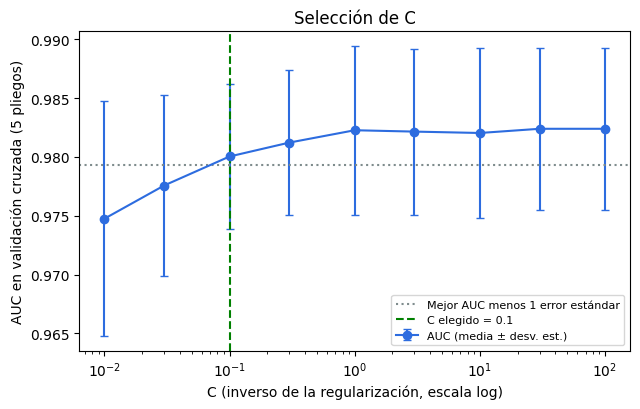

In [12]:
# Figura 5: selección de C
fig, ax = plt.subplots(figsize=(6.5, 4.2))
ax.errorbar(VALORES_C, res["mean_test_auc"], yerr=res["std_test_auc"], marker="o",
            color=AZUL, capsize=3, label="AUC (media ± desv. est.)")
ax.axhline(limite, color=GRIS, linestyle=":", label="Mejor AUC menos 1 error estándar")
ax.axvline(C_optimo, color="green", linestyle="--", label=f"C elegido = {C_optimo:g}")
ax.set_xscale("log")
ax.set_xlabel("C (inverso de la regularización, escala log)")
ax.set_ylabel("AUC en validación cruzada (5 pliegos)")
ax.set_title("Selección de C"); ax.legend(fontsize=8, loc="lower right")
fig.tight_layout(); fig.savefig("figures/fig05_seleccion_C.png", dpi=150); plt.show()

El AUC apenas cambia a partir de C = 0,3 (de 0,981 a 0,982), así que la regla elige C = 0,1, cuyo AUC (0,980) está dentro de un error estándar del máximo. El *recall* con el umbral 0,5 sí sube con C, pero eso se corrige después ajustando el umbral.

## 8. Comparación de variantes con validación cruzada

Antes de fijar el modelo se compara, solo con datos de entrenamiento, contra una línea base y contra tres variantes. Todas usan el umbral por defecto (0,5) y los mismos pliegos.

In [13]:
scoring = {"exactitud": "accuracy",
           "precision": make_scorer(precision_score, zero_division=0),
           "recall": "recall", "f1": "f1", "auc": "roc_auc"}

n = X_ent.shape[1]
modelos = {
    "Línea base (siempre benigno)": (DummyClassifier(strategy="most_frequent"), X_ent),
    f"Regresión logística, {n} variables finales, C={C_optimo:g}": (crear_pipeline(C_optimo), X_ent),
    f"Regresión logística, {n} variables finales, C={C_optimo:g}, pesos balanceados":
        (crear_pipeline(C_optimo, class_weight="balanced"), X_ent),
    f"Regresión logística, {X_cand_ent.shape[1]} candidatas (con colinealidad), C={C_optimo:g}":
        (crear_pipeline(C_optimo), X_cand_ent),
    f"Regresión logística, {X30_ent.shape[1]} variables, C={C_optimo:g}":
        (crear_pipeline(C_optimo), X30_ent),
}

filas = []
for nombre, (modelo, X) in modelos.items():
    r = cross_validate(modelo, X, y_ent, cv=cv, scoring=scoring)
    filas.append({"modelo": nombre,
                  **{m: f"{r[f'test_{m}'].mean():.3f} ± {r[f'test_{m}'].std():.3f}" for m in scoring}})
comparacion = pd.DataFrame(filas)
pd.set_option("display.max_colwidth", 90)
comparacion

,modelo,exactitud,precision,recall,f1,auc
0,Línea base (siempre benigno),0.627 ± 0.005,0.000 ± 0.000,0.000 ± 0.000,0.000 ± 0.000,0.500 ± 0.000
1,"Regresión logística, 5 variables finales, C=0.1",0.934 ± 0.025,0.971 ± 0.015,0.849 ± 0.060,0.905 ± 0.039,0.980 ± 0.006
2,"Regresión logística, 5 variables finales, C=0.1, pesos balanceados",0.927 ± 0.020,0.911 ± 0.021,0.893 ± 0.058,0.901 ± 0.030,0.980 ± 0.006
3,"Regresión logística, 6 candidatas (con colinealidad), C=0.1",0.934 ± 0.016,0.958 ± 0.013,0.862 ± 0.042,0.907 ± 0.024,0.982 ± 0.006
4,"Regresión logística, 30 variables, C=0.1",0.967 ± 0.009,0.993 ± 0.013,0.918 ± 0.025,0.954 ± 0.013,0.992 ± 0.006


- Línea base: acierta el 62,7 % pero detecta 0 % de los malignos y tiene AUC 0,5. Cualquier modelo útil debe superar esto en *recall* y AUC, no solo en exactitud.
- Pesos balanceados: sube el *recall* (0,893 frente a 0,849) y baja la precisión (0,911 frente a 0,971) con el mismo AUC (0,980). Es un intercambio equivalente a bajar el umbral, que se hará de forma explícita.
- Seis candidatas: casi no mejora (AUC 0,982 frente a 0,980) a pesar de añadir una variable, lo que respalda eliminar `puntos_concavos` por colinealidad.
- Treinta variables: es claramente mejor (AUC 0,992, *recall* 0,918, precisión 0,993). Es el costo de la decisión de interpretabilidad: el modelo de cinco variables sacrifica algo de desempeño a cambio de coeficientes que se pueden leer. Si solo importara predecir, convendría el de treinta.

## 9. Entrenamiento final: `predict()` frente a `predict_proba()`

`predict()` entrega la clase final (0 o 1). `predict_proba()` entrega la probabilidad de cada clase. En un problema clínico la segunda informa más: un caso con probabilidad de 0,52 de ser maligno no genera la misma confianza que uno con 0,99, aunque `predict()` los clasifique igual.

In [14]:
modelo_final = crear_pipeline(C_optimo).fit(X_ent, y_ent)
print("Iteraciones de lbfgs hasta converger:", int(np.max(modelo_final.named_steps["clasificador"].n_iter_)))

prob_pru = modelo_final.predict_proba(X_pru)[:, 1]     # probabilidad de maligno
pred_defecto = modelo_final.predict(X_pru)             # clase con umbral 0,5

comparacion_pred = pd.DataFrame({
    "Real": y_pru.map({0: "benigno", 1: "maligno"}).values,
    "Predicho": pd.Series(pred_defecto).map({0: "benigno", 1: "maligno"}).values,
    "Prob_maligno": prob_pru.round(3),
})
print("Primeros 8 casos de prueba:")
print(comparacion_pred.head(8).to_string())
print("\nCasos dudosos (probabilidad entre 0.30 y 0.70):", int(((prob_pru > 0.3) & (prob_pru < 0.7)).sum()),
      "de", len(prob_pru))

Iteraciones de lbfgs hasta converger: 8
Primeros 8 casos de prueba:
      Real Predicho  Prob_maligno
0  maligno  maligno         0.991
1  benigno  benigno         0.318
2  maligno  maligno         0.894
3  benigno  benigno         0.017
4  benigno  benigno         0.446
5  benigno  benigno         0.105
6  benigno  benigno         0.046
7  benigno  benigno         0.074

Casos dudosos (probabilidad entre 0.30 y 0.70): 21 de 143


## 10. Ajuste del umbral de decisión

El umbral convierte la probabilidad en una clase; 0,5 es solo el valor por defecto (Google for Developers, 2025d). Subirlo reduce los falsos positivos y aumenta los falsos negativos; bajarlo hace lo contrario. Como aquí un falso negativo es más grave, se busca el umbral que maximiza la F2, una media entre precisión y *recall* que pesa el *recall* cuatro veces más que la precisión.

La búsqueda se hace solo con el entrenamiento, con `TunedThresholdClassifierCV` (validación cruzada de 5 pliegos). El conjunto de prueba no interviene.

Umbral elegido: 0.285  (F2 en validación cruzada = 0.940)


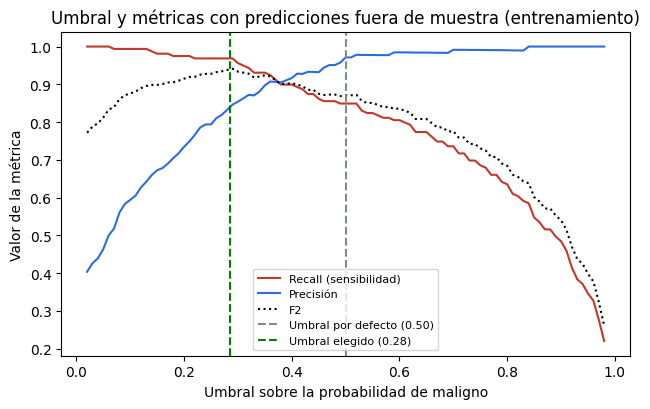

In [15]:
ajustado = TunedThresholdClassifierCV(
    estimator=clone(crear_pipeline(C_optimo)),
    scoring=make_scorer(fbeta_score, beta=BETA_UMBRAL),
    cv=cv, refit=True)
ajustado.fit(X_ent, y_ent)
umbral = float(ajustado.best_threshold_)
print(f"Umbral elegido: {umbral:.3f}  (F2 en validación cruzada = {ajustado.best_score_:.3f})")

# Probabilidades fuera de muestra del entrenamiento, solo para dibujar la curva
prob_oof = cross_val_predict(clone(crear_pipeline(C_optimo)), X_ent, y_ent, cv=cv,
                             method="predict_proba")[:, 1]
umbrales = np.linspace(0.02, 0.98, 97)
prec = [precision_score(y_ent, prob_oof >= u, zero_division=0) for u in umbrales]
reca = [recall_score(y_ent, prob_oof >= u) for u in umbrales]
f2 = [fbeta_score(y_ent, prob_oof >= u, beta=BETA_UMBRAL, zero_division=0) for u in umbrales]

# Figura 6: umbral y métricas (predicciones fuera de muestra del entrenamiento)
fig, ax = plt.subplots(figsize=(6.5, 4.2))
ax.plot(umbrales, reca, color=ROJO, label="Recall (sensibilidad)")
ax.plot(umbrales, prec, color=AZUL, label="Precisión")
ax.plot(umbrales, f2, color="black", linestyle=":", label="F2")
ax.axvline(0.5, color=GRIS, linestyle="--", label="Umbral por defecto (0.50)")
ax.axvline(umbral, color="green", linestyle="--", label=f"Umbral elegido ({umbral:.2f})")
ax.set_xlabel("Umbral sobre la probabilidad de maligno"); ax.set_ylabel("Valor de la métrica")
ax.set_title("Umbral y métricas con predicciones fuera de muestra (entrenamiento)")
ax.legend(fontsize=8, loc="lower center")
fig.tight_layout(); fig.savefig("figures/fig06_umbral_oof.png", dpi=150); plt.show()

Con un umbral cercano a 0,285, el *recall* sube a costa de la precisión. Que sea un umbral más bajo que 0,5 significa que se exige menos evidencia para marcar un caso como sospechoso de malignidad. Esa es una decisión de política clínica, no solo estadística: este valor refleja que el *recall* pesa cuatro veces más que la precisión, y otro peso daría otro umbral.

## 11. Evaluación en el conjunto de prueba

Se usa una sola vez. Se informan métricas con el umbral por defecto y con el ajustado. La clase positiva es maligno, así que *recall* es la sensibilidad y especificidad es la proporción de benignos reconocidos como tales (Google for Developers, 2026a; Romero Ibarra, 2025). El AUC y la precisión promedio (AUC-PR) no dependen del umbral.

In [16]:
def calcular_metricas(y_real, prob, umbral=0.5):
    y_real = np.asarray(y_real)
    pred = (np.asarray(prob) >= umbral).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_real, pred, labels=[0, 1]).ravel()
    return {"umbral": umbral, "vn": tn, "fp": fp, "fn": fn, "vp": tp,
            "exactitud": accuracy_score(y_real, pred),
            "exactitud_balanceada": balanced_accuracy_score(y_real, pred),
            "precision": precision_score(y_real, pred, zero_division=0),
            "recall": recall_score(y_real, pred),
            "especificidad": tn / (tn + fp),
            "f1": f1_score(y_real, pred),
            "f2": fbeta_score(y_real, pred, beta=BETA_UMBRAL),
            "mcc": matthews_corrcoef(y_real, pred),
            "auc_roc": roc_auc_score(y_real, prob),
            "auc_pr": average_precision_score(y_real, prob),
            "brier": brier_score_loss(y_real, prob)}


def bootstrap_ic(y_real, prob, umbral, metricas=("recall", "precision", "auc_roc")):
    # Intervalo de confianza percentil del 95 % sobre el conjunto de prueba
    y_real, prob = np.asarray(y_real), np.asarray(prob)
    rng = np.random.default_rng(SEMILLA)
    muestras = {m: [] for m in metricas}
    for _ in range(N_BOOTSTRAP):
        idx = rng.integers(0, len(y_real), len(y_real))
        if len(np.unique(y_real[idx])) < 2:
            continue
        valores = calcular_metricas(y_real[idx], prob[idx], umbral)
        for m in metricas:
            muestras[m].append(valores[m])
    return {m: (float(np.percentile(v, 2.5)), float(np.percentile(v, 97.5)))
            for m, v in muestras.items()}


m_defecto = calcular_metricas(y_pru, prob_pru, 0.5)
m_ajustado = calcular_metricas(y_pru, prob_pru, umbral)
ic_defecto = bootstrap_ic(y_pru, prob_pru, 0.5)
ic_ajustado = bootstrap_ic(y_pru, prob_pru, umbral)

conteos = ["vn", "fp", "fn", "vp"]
tabla = pd.DataFrame({"umbral 0.50": m_defecto, f"umbral {umbral:.2f}": m_ajustado}).drop(index="umbral")
tabla = tabla.astype(object)
for fila in tabla.index:       # conteos como enteros, métricas con 3 decimales
    tabla.loc[fila] = [int(v) if fila in conteos else round(float(v), 3) for v in tabla.loc[fila]]
tabla

,umbral 0.50,umbral 0.28
vn,88,81
fp,2,9
fn,7,2
vp,46,51
exactitud,0.937,0.923
exactitud_balanceada,0.923,0.931
precision,0.958,0.85
recall,0.868,0.962
especificidad,0.978,0.9
f1,0.911,0.903


In [17]:
print("Reporte de clasificación con umbral por defecto (0.50):")
print(classification_report(y_pru, (prob_pru >= 0.5).astype(int), target_names=["benigno", "maligno"]))
print(f"Reporte de clasificación con umbral ajustado ({umbral:.2f}):")
print(classification_report(y_pru, (prob_pru >= umbral).astype(int), target_names=["benigno", "maligno"]))

print("Intervalos de confianza del 95 % (bootstrap, 1000 remuestras):")
for nombre, ic in [("umbral 0.50", ic_defecto), (f"umbral {umbral:.2f}", ic_ajustado)]:
    print(" ", nombre, {k: f"[{v[0]:.3f}, {v[1]:.3f}]" for k, v in ic.items()})

Reporte de clasificación con umbral por defecto (0.50):
              precision    recall  f1-score   support

     benigno       0.93      0.98      0.95        90
     maligno       0.96      0.87      0.91        53

    accuracy                           0.94       143
   macro avg       0.94      0.92      0.93       143
weighted avg       0.94      0.94      0.94       143

Reporte de clasificación con umbral ajustado (0.28):
              precision    recall  f1-score   support

     benigno       0.98      0.90      0.94        90
     maligno       0.85      0.96      0.90        53

    accuracy                           0.92       143
   macro avg       0.91      0.93      0.92       143
weighted avg       0.93      0.92      0.92       143

Intervalos de confianza del 95 % (bootstrap, 1000 remuestras):
  umbral 0.50 {'recall': '[0.771, 0.945]', 'precision': '[0.894, 1.000]', 'auc_roc': '[0.973, 0.997]'}
  umbral 0.28 {'recall': '[0.902, 1.000]', 'precision': '[0.750, 0.930]

In [18]:
def bootstrap_diferencia(y_real, prob, umbral_a, umbral_b, metrica):
    # Diferencia (b menos a) entre dos umbrales sobre las mismas remuestras (bootstrap pareado)
    y_real, prob = np.asarray(y_real), np.asarray(prob)
    rng = np.random.default_rng(SEMILLA)
    difs = []
    for _ in range(N_BOOTSTRAP):
        idx = rng.integers(0, len(y_real), len(y_real))
        if len(np.unique(y_real[idx])) < 2:
            continue
        difs.append(calcular_metricas(y_real[idx], prob[idx], umbral_b)[metrica]
                    - calcular_metricas(y_real[idx], prob[idx], umbral_a)[metrica])
    punto = m_ajustado[metrica] - m_defecto[metrica]
    return punto, (float(np.percentile(difs, 2.5)), float(np.percentile(difs, 97.5)))


for metrica in ("recall", "precision"):
    punto, (inf_, sup_) = bootstrap_diferencia(y_pru, prob_pru, 0.5, umbral, metrica)
    print(f"Cambio en {metrica} al pasar de 0.50 a {umbral:.2f}: {punto:+.3f}  (IC 95 %: {inf_:+.3f} a {sup_:+.3f})")

Cambio en recall al pasar de 0.50 a 0.28: +0.094  (IC 95 %: +0.033 a +0.177)


Cambio en precision al pasar de 0.50 a 0.28: -0.108  (IC 95 %: -0.196 a -0.038)


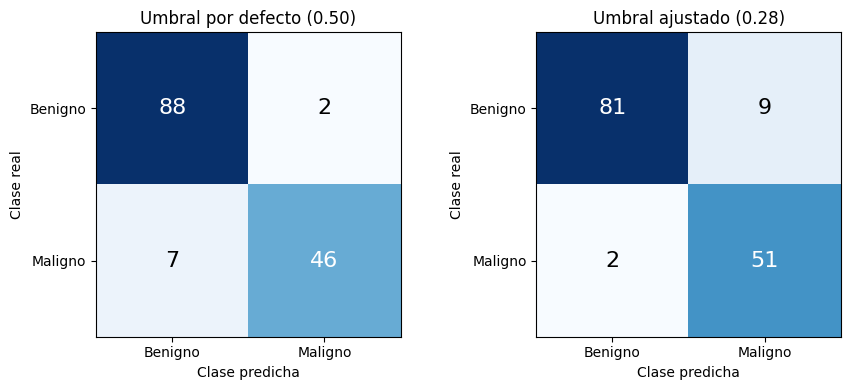

In [19]:
# Figura 7: matrices de confusión con ambos umbrales
fig, ejes = plt.subplots(1, 2, figsize=(9, 4))
for ax, u, titulo in [(ejes[0], 0.5, "Umbral por defecto"), (ejes[1], umbral, "Umbral ajustado")]:
    m = confusion_matrix(y_pru, (prob_pru >= u).astype(int), labels=[0, 1])
    ax.imshow(m, cmap="Blues")
    for i in range(2):
        for j in range(2):
            ax.text(j, i, m[i, j], ha="center", va="center", fontsize=16,
                    color="white" if m[i, j] > m.max() / 2 else "black")
    ax.set_xticks([0, 1], ["Benigno", "Maligno"]); ax.set_yticks([0, 1], ["Benigno", "Maligno"])
    ax.set_xlabel("Clase predicha"); ax.set_ylabel("Clase real")
    ax.set_title(f"{titulo} ({u:.2f})")
fig.tight_layout(); fig.savefig("figures/fig07_matrices_confusion.png", dpi=150); plt.show()

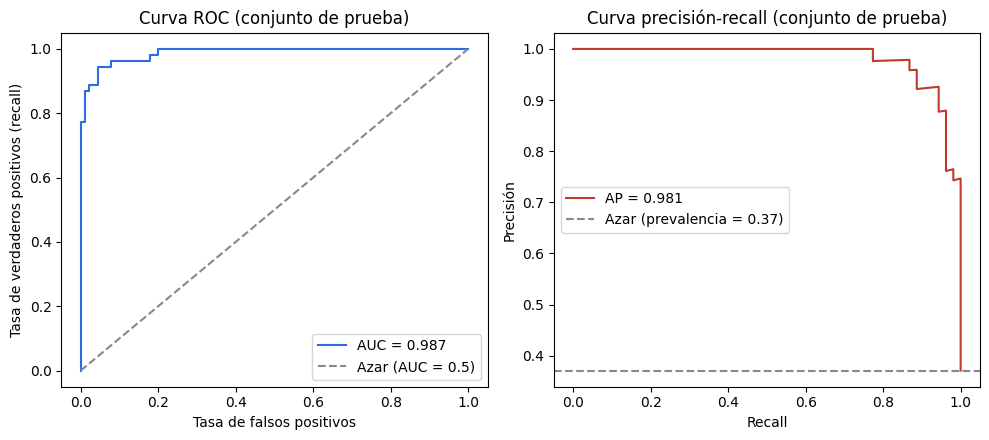

In [20]:
# Figura 8: curvas ROC y precisión-recall en el conjunto de prueba
fpr, tpr, _ = roc_curve(y_pru, prob_pru)
prec_c, rec_c, _ = precision_recall_curve(y_pru, prob_pru)
fig, ejes = plt.subplots(1, 2, figsize=(10, 4.5))
ejes[0].plot(fpr, tpr, color=AZUL, label=f"AUC = {roc_auc_score(y_pru, prob_pru):.3f}")
ejes[0].plot([0, 1], [0, 1], "--", color=GRIS, label="Azar (AUC = 0.5)")
ejes[0].set_xlabel("Tasa de falsos positivos"); ejes[0].set_ylabel("Tasa de verdaderos positivos (recall)")
ejes[0].set_title("Curva ROC (conjunto de prueba)"); ejes[0].legend()
ejes[1].plot(rec_c, prec_c, color=ROJO, label=f"AP = {average_precision_score(y_pru, prob_pru):.3f}")
ejes[1].axhline(np.mean(y_pru), linestyle="--", color=GRIS, label=f"Azar (prevalencia = {np.mean(y_pru):.2f})")
ejes[1].set_xlabel("Recall"); ejes[1].set_ylabel("Precisión")
ejes[1].set_title("Curva precisión-recall (conjunto de prueba)"); ejes[1].legend()
fig.tight_layout(); fig.savefig("figures/fig08_roc_pr.png", dpi=150); plt.show()

Con el umbral 0,50 la exactitud es 0,937, la precisión 0,958 y el *recall* 0,868. De 53 tumores malignos el modelo detecta 46 y deja pasar 7; solo marca 2 casos benignos como malignos. Marca con prudencia, pero omite demasiados malignos para un uso clínico.

Con el umbral ajustado (0,285) el *recall* sube a 0,962: se detectan 51 de 53 y se pasan por alto 2. A cambio hay 9 falsas alarmas (antes 2), y la precisión baja a 0,850 y la exactitud a 0,923. En términos clínicos, 5 tumores malignos más detectados a cambio de 7 pruebas adicionales sobre casos benignos.

El AUC es 0,987 (IC 95 %: 0,973 a 0,997) y equivale a la probabilidad de que el modelo asigne una probabilidad mayor a un caso maligno elegido al azar que a uno benigno (Google for Developers, 2025a). No cambia al mover el umbral, lo que permite ajustarlo sin perder poder discriminante.

Con solo 143 casos de prueba las cifras puntuales son menos firmes de lo que parecen: el *recall* con umbral 0,50 tiene un IC 95 % de 0,771 a 0,945, y con el umbral ajustado de 0,902 a 1,000. Para comparar los dos umbrales se usa un bootstrap pareado (mismas remuestras): el *recall* sube 0,094 (IC 95 %: 0,033 a 0,177) y la precisión baja 0,108 (IC 95 %: de -0,196 a -0,038). Ambos intervalos excluyen el cero, así que el intercambio se mantiene al remuestrear los casos de prueba.

El puntaje de Brier es 0,051, frente a unos 0,23 de un modelo que predijera siempre la prevalencia, así que las probabilidades son útiles. No se dibujó una curva de calibración, que sería el paso previo a interpretarlas como riesgos.

## 12. Interpretación de los coeficientes

Como las variables están estandarizadas, los coeficientes son comparables: cada uno es el cambio en el logaritmo de las probabilidades (*log-odds*) de maligno por cada desviación estándar de aumento. Al aplicar `exp()` se obtiene la razón de momios: cuántas veces se multiplican las probabilidades de maligno (Lee, 2025). Los intervalos salen de reajustar el modelo en 500 remuestras bootstrap del entrenamiento.

In [21]:
coef = modelo_final.named_steps["clasificador"].coef_[0]

rng = np.random.default_rng(SEMILLA)
boot = []
for _ in range(N_BOOTSTRAP_COEF):
    idx = rng.integers(0, len(X_ent), len(X_ent))
    m = clone(crear_pipeline(C_optimo)).fit(X_ent.iloc[idx], y_ent.iloc[idx])
    boot.append(m.named_steps["clasificador"].coef_[0])
boot = np.array(boot)

tabla_coef = pd.DataFrame({
    "variable": finales, "coeficiente": coef, "razon_momios": np.exp(coef),
    "ic95_inferior": np.exp(np.percentile(boot, 2.5, axis=0)),
    "ic95_superior": np.exp(np.percentile(boot, 97.5, axis=0)),
    "vif": calcular_vif(X_ent).values,
}).sort_values("coeficiente", ascending=False).round(3)
tabla_coef

,variable,coeficiente,razon_momios,ic95_inferior,ic95_superior,vif
0,radio,1.799,6.043,4.961,7.305,2.097
3,concavidad,0.862,2.368,1.841,3.240,3.092
1,textura,0.769,2.157,1.832,2.535,1.152
2,suavidad,0.593,1.809,1.483,2.194,1.783
4,simetria,0.245,1.277,1.049,1.586,1.679


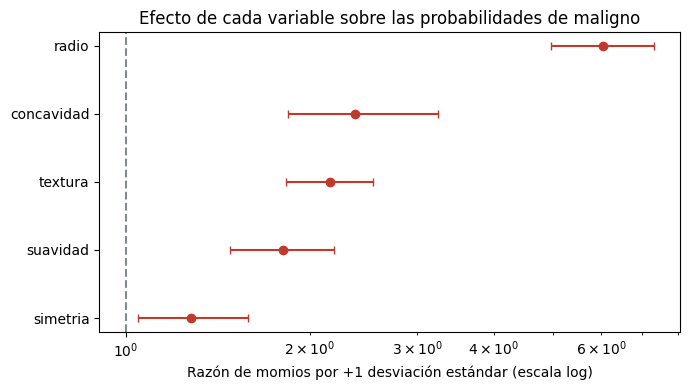

In [22]:
# Figura 9: razones de momios con intervalo de confianza
orr = np.exp(coef)
inf, sup = np.exp(np.percentile(boot, 2.5, axis=0)), np.exp(np.percentile(boot, 97.5, axis=0))
orden = np.argsort(orr)
fig, ax = plt.subplots(figsize=(7, 4))
y_pos = np.arange(len(finales))
ax.errorbar(orr[orden], y_pos, xerr=[orr[orden] - inf[orden], sup[orden] - orr[orden]],
            fmt="o", color=ROJO, capsize=3)
ax.axvline(1, color=GRIS, linestyle="--")
ax.set_yticks(y_pos, np.array(finales)[orden]); ax.set_xscale("log")
ax.set_xlabel("Razón de momios por +1 desviación estándar (escala log)")
ax.set_title("Efecto de cada variable sobre las probabilidades de maligno")
fig.tight_layout(); fig.savefig("figures/fig09_razones_de_momios.png", dpi=150); plt.show()

Los cinco coeficientes son positivos: valores más altos de cualquiera de las variables aumentan las probabilidades de maligno. El radio domina: por cada desviación estándar de aumento, las probabilidades se multiplican por 6,0 (IC 95 %: 5,0 a 7,3). Siguen concavidad (2,4), textura (2,2) y suavidad (1,8). La simetría es la más débil (1,3), con un intervalo (1,05 a 1,59) que casi toca 1. Sin colinealidad (VIF máximo de 3,1) los intervalos son estrechos y el orden de las variables es estable. Son asociaciones del modelo y no deben leerse como causas.

## 13. Discusión y conclusiones

El modelo de cinco variables separa muy bien los tumores (AUC 0,987), pero con el umbral por defecto omite 7 de 53 malignos. Ajustar el umbral con F2, usando solo el entrenamiento, reduce las omisiones a 2 a cambio de 7 falsas alarmas adicionales. La mejora del *recall* se sostiene en los intervalos de confianza y no depende de una sola partición.

Quedan cuatro ideas:
- La exactitud no basta: la línea base ya acierta el 62,7 % sin detectar ningún maligno (Google for Developers, 2025b).
- Los hiperparámetros se justifican con validación cruzada, y los empates se resuelven con un criterio explícito (un error estándar) en lugar de la intuición.
- El umbral es una decisión sobre costos de error: cambiarlo redistribuye los errores del modelo sin mejorarlo.
- Con variables colineales el modelo predice bien, pero sus coeficientes no se pueden leer por separado.

Las limitaciones son estas:
- Con 143 casos de prueba, los intervalos de confianza son amplios.
- Se descartaron variables por interpretabilidad: el modelo con las 30 variables rinde mejor (AUC 0,992 en validación cruzada).
- Los datos provienen de un único centro y protocolo de digitalización; no hay garantía de que funcionen igual con otros equipos o poblaciones.
- No se evaluó la calibración de las probabilidades.
- El umbral depende del peso elegido (F2); en un uso real debería definirlo el personal clínico.

Como trabajo futuro quedan la curva de calibración, la validación con datos externos y la comparación con árboles de decisión, Random Forest y SVM (Semanas 7 y 8).

## 14. Referencias

- Cuenta de Alto Costo. (2024, 19 de octubre). *Día mundial del cáncer de mama*. https://cuentadealtocosto.org/noticias/dia-mundial-del-cancer-de-mama/
- Google for Developers. (2025a, 1 de octubre). *Clasificación: ROC y AUC*. Curso intensivo de aprendizaje automático. https://developers.google.com/machine-learning/crash-course/classification/roc-and-auc?hl=es-419
- Google for Developers. (2025b, 28 de agosto). *Conjuntos de datos: Conjuntos de datos con desequilibrio de clases*. Curso intensivo de aprendizaje automático. https://developers.google.com/machine-learning/crash-course/overfitting/imbalanced-datasets?hl=es-419
- Google for Developers. (2025c, 3 de enero). *Conjuntos de datos: división del conjunto de datos original*. Curso intensivo de aprendizaje automático. https://developers.google.com/machine-learning/crash-course/overfitting/dividing-datasets?hl=es-419
- Google for Developers. (2025d, 1 de octubre). *Umbrales y matriz de confusión*. Curso intensivo de aprendizaje automático. https://developers.google.com/machine-learning/crash-course/classification/thresholding?hl=es-419
- Google for Developers. (2026a, 5 de febrero). *Clasificación: Exactitud, recuperación, precisión y métricas relacionadas*. Curso intensivo de aprendizaje automático. https://developers.google.com/machine-learning/crash-course/classification/accuracy-precision-recall?hl=es-419
- Google for Developers. (2026b, 12 de mayo). *Regresión logística: pérdida y regularización*. Curso intensivo de aprendizaje automático. https://developers.google.com/machine-learning/crash-course/logistic-regression/model-training?hl=es-419
- Lee, F. (2025, 14 de mayo). *¿Qué es la regresión logística?* IBM. https://www.ibm.com/mx-es/topics/logistic-regression
- Organización Mundial de la Salud. (2026, 3 de julio). *Cáncer de mama* [Nota descriptiva]. https://www.who.int/es/news-room/fact-sheets/detail/breast-cancer
- Romero Ibarra, J. L. (2025). Análisis integral de algoritmos de clasificación en aprendizaje automático: perspectivas, comparaciones y aplicaciones. *Serie Científica de la Universidad de las Ciencias Informáticas, 18*(1), 283-304. http://scielo.sld.cu/scielo.php?pid=S2306-24952025000100283&script=sci_abstract